# 11-5 Plotting with pandas

See also the [pandas plotting guide](https://pandas.pydata.org/docs/user_guide/visualization.html#visualization)

Pandas dataFrames have built-in `plot` functions:

In [45]:
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib widget
import numpy as np



Let's start by reloading the dataFrames from previous notebooks.

In [82]:
grades = pd.read_csv("grades.csv", skipinitialspace=True, index_col=2)
titanic = pd.read_csv("titanic.csv")
gp = pd.read_csv("1810000101_databaseLoadingData.csv", skipinitialspace=True, index_col = 0, parse_dates = [0])

url = 'https://raw.githubusercontent.com/pandas-dev/pandas/refs/heads/main/doc/data/air_quality_no2.csv'
aq = pd.read_csv(url, index_col = 0, parse_dates=[0])

Let's plot a histogram of the exam 1 grades

(array([ 0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,
         0.,  0., 14., 60., 82., 75., 20.]),
 array([  0.,   5.,  10.,  15.,  20.,  25.,  30.,  35.,  40.,  45.,  50.,
         55.,  60.,  65.,  70.,  75.,  80.,  85.,  90.,  95., 100.]),
 <BarContainer object of 20 artists>)

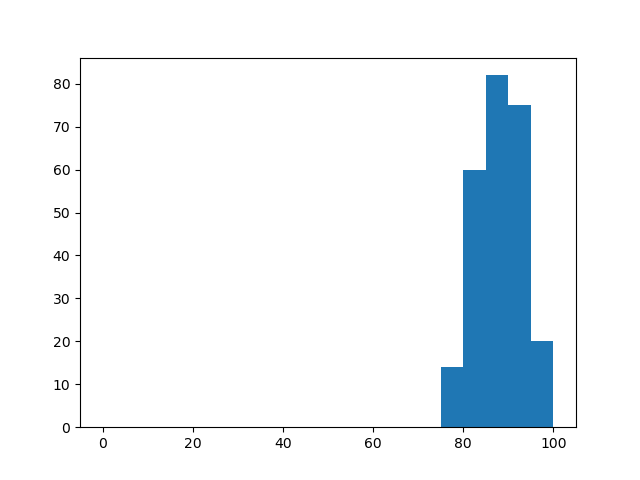

In [73]:
plt.close('all')
fig, ax = plt.subplots()
ax.hist(grades['Exam1_mark'], bins = np.linspace(0,100,21), label = 'Exam 1')

matplotlib can use a more concise way by specifying the data source:


(array([ 0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,
         0.,  0., 14., 60., 82., 75., 20.]),
 array([  0.,   5.,  10.,  15.,  20.,  25.,  30.,  35.,  40.,  45.,  50.,
         55.,  60.,  65.,  70.,  75.,  80.,  85.,  90.,  95., 100.]),
 <BarContainer object of 20 artists>)

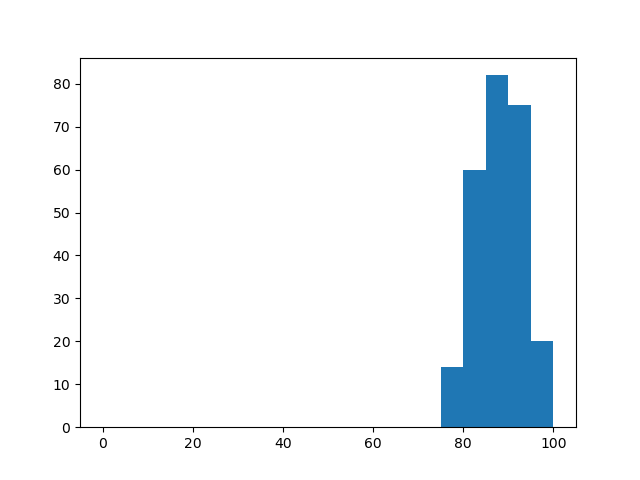

In [74]:
plt.close('all')
fig, ax = plt.subplots()
ax.hist('Exam1_mark', data = grades, bins = np.linspace(0,100,21))


pandas provide an even simpler way to generate plots:

Text(0, 0.5, 'count')

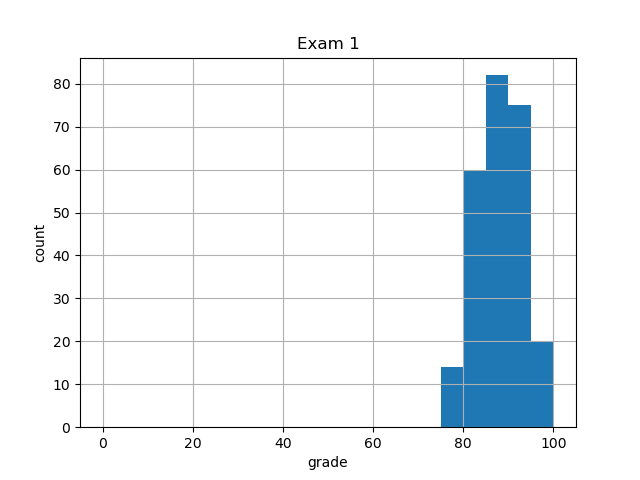

In [75]:
plt.close('all')
p = grades['Exam1_mark'].hist(bins = np.linspace(0,100,21))
p.set_title('Exam 1')
p.set_xlabel('grade')
p.set_ylabel('count')

Let's plot the air quality data:

<Axes: xlabel='datetime'>

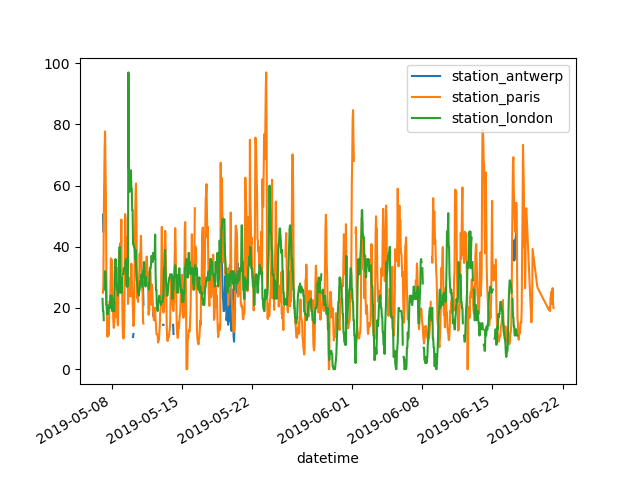

In [77]:
plt.close('all')
aq.plot()

<Axes: xlabel='datetime'>

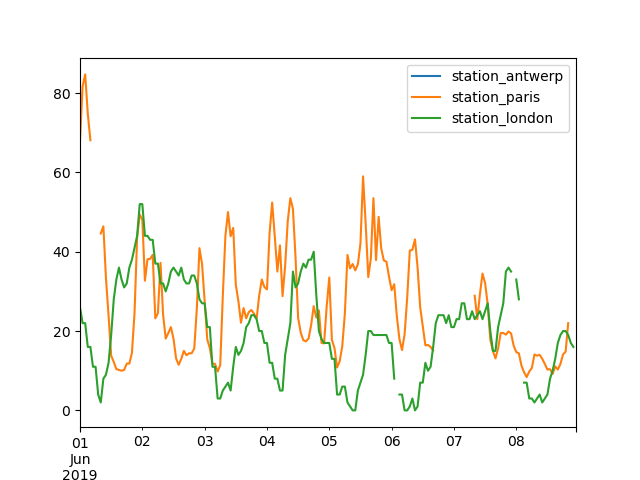

In [79]:
# Let's only plot the first weeks of June 2019:
aq.loc["2019-06-01":"2019-06-08"].plot()

In [ ]:
gp2 = gp.copy()
gp2[gp2['GEO'] == 'Toronto, Ontario'][['date', 'VALUE']].plot(x='date', y = 'VALUE', label = 'gas price')


Let's compare gas prices in different locations

In [129]:
loc = gp.GEO.unique()
print(loc)

['Canada' "St. John's, Newfoundland and Labrador"
 'Charlottetown and Summerside, Prince Edward Island'
 'Halifax, Nova Scotia' 'Saint John, New Brunswick' 'Québec, Quebec'
 'Montréal, Quebec' 'Ottawa-Gatineau, Ontario part, Ontario/Quebec'
 'Toronto, Ontario' 'Thunder Bay, Ontario' 'Winnipeg, Manitoba'
 'Regina, Saskatchewan' 'Saskatoon, Saskatchewan' 'Edmonton, Alberta'
 'Calgary, Alberta' 'Vancouver, British Columbia'
 'Victoria, British Columbia' 'Whitehorse, Yukon'
 'Yellowknife, Northwest Territories']


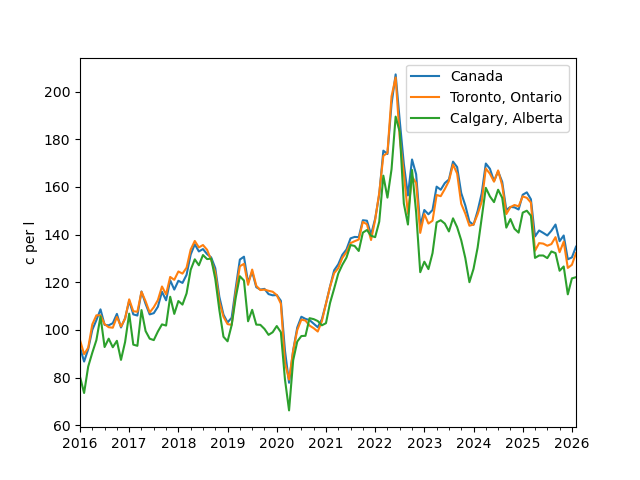

In [130]:
plt.close('all')
fig, ax = plt.subplots()
for l in ('Canada', 'Toronto, Ontario', 'Calgary, Alberta'):
    gp[gp.GEO == l]['VALUE'].plot(xlabel = '', ylabel = 'c per l', label = l)
ax.legend()

In [ ]:
Aniother way would be to group the data by city then extract some groups

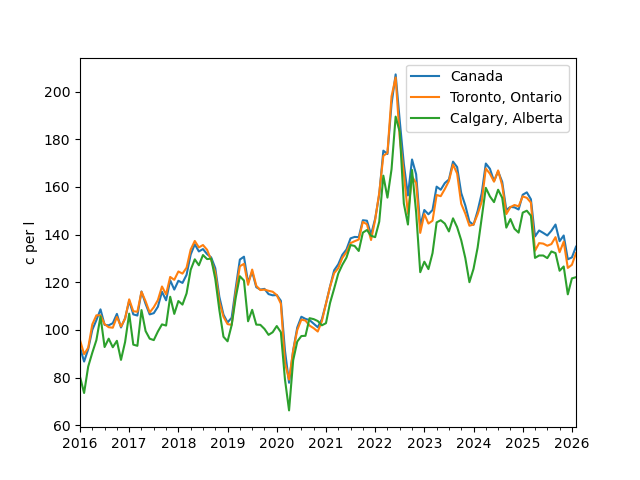

In [133]:
gp2 = gp.groupby('GEO')
plt.close('all')
fig, ax = plt.subplots()
for l in ('Canada', 'Toronto, Ontario', 'Calgary, Alberta'):
    gp2.get_group(l)['VALUE'].plot(xlabel = '', ylabel = 'c per l', label = l, ax = ax)
ax.legend()

## Various types of bar plots


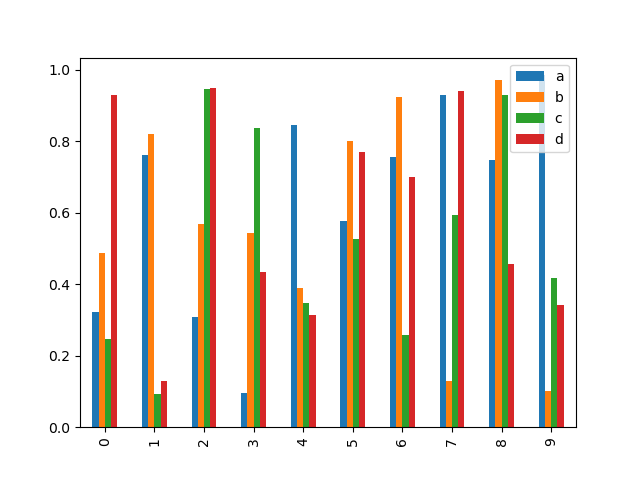

In [135]:
# we generate some random values in DataFrame
df2 = pd.DataFrame(np.random.rand(10, 4), columns=["a", "b", "c", "d"])

df2.plot.bar();


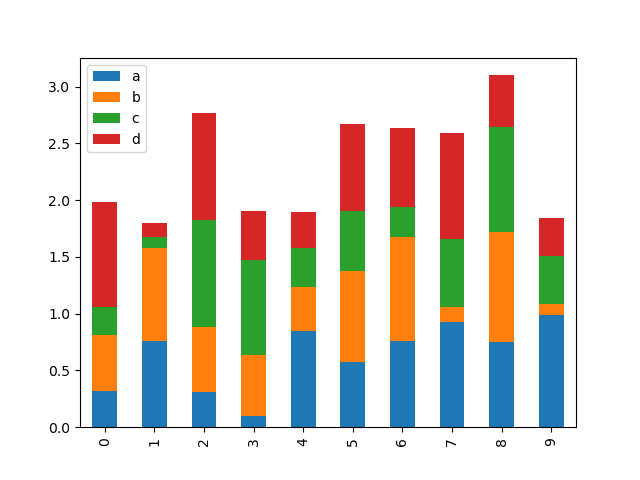

In [136]:
plt.close('all')
df2.plot.bar(stacked=True);